<a href="https://colab.research.google.com/github/mersalas/ecosa/blob/main/ecoli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Install packages**

In [1]:
# Must install the following packages in python 3.8
#!pip install deep-forest
#!pip install pyforest
#!pip install umap-learn
#!pip install scikit-optimize
#!pip install shap

#**Load dataset**

In [2]:
# Import the necessary libraries
from pyforest import*
lazy_imports() # load most libraries
import random, umap, warnings, time, joblib
from sklearn.preprocessing import Normalizer
from skopt import BayesSearchCV
from datetime import timedelta
from skopt.plots import plot_objective
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from deepforest import CascadeForestClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, auc, roc_auc_score, matthews_corrcoef, classification_report # evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve # plots
import shap # feature importance

2024-09-05 01:42:00.371495: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-05 01:42:00.633662: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-05 01:42:01.355745: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
# Loading the dataset
url = 'https://raw.githubusercontent.com/mersalas/ecosa/main/dataset/Ecoprop_51024.csv'
data = pd.read_csv(url)

X = data.loc[:, ~data.columns.isin(['id', 'Ecoli'])]
y = data.iloc[:, 1].values
cols = X.columns

# Normalize the data
normalizer = Normalizer()
X_norm = normalizer.fit_transform(X)

# Convert X_norm into DataFrame
X_norm = pd.DataFrame(X_norm, columns=cols)
print(X_norm.shape)
X_norm.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(2652, 1026)


,Q,frac_CC,ECFP0,ECFP1,ECFP2,ECFP3,ECFP4,ECFP5,ECFP6,ECFP7,...,ECFP1014,ECFP1015,ECFP1016,ECFP1017,ECFP1018,ECFP1019,ECFP1020,ECFP1021,ECFP1022,ECFP1023
0,0.062237,-0.004313,0.071184,0.055165,0.061040,0.046678,0.024895,0.000000,0.000000,0.0,...,0.000000,0.000000,0.060681,0.046678,0.000000,0.046678,0.000000,0.0,0.0,0.000000
1,0.009098,-0.035888,0.015012,0.027294,0.035692,0.040941,0.049129,0.081882,0.191058,0.0,...,0.000000,0.081882,0.024565,0.054588,0.000000,0.000000,0.000000,0.0,0.0,0.027294
2,0.097834,-0.032858,0.051363,0.017788,0.060206,-0.024459,-0.039134,-0.024459,0.000000,0.0,...,0.097834,-0.024459,0.029350,0.000000,0.048917,0.000000,0.048917,0.0,0.0,0.000000
3,0.130178,-0.020615,0.047596,0.026627,0.067593,-0.024408,-0.019527,-0.024408,0.000000,0.0,...,0.048817,-0.024408,0.029290,0.000000,0.048817,0.000000,0.048817,0.0,0.0,0.000000
4,0.000000,-0.003154,-0.006011,-0.007286,0.018494,0.040071,0.000000,-0.040071,0.000000,0.0,...,0.000000,-0.040071,-0.008014,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000


In [4]:
# Check missing or null values
print(f'There are {pd.concat([data], axis=1).isnull().sum().sum()} missing values \n')

# Count target
print(f'AMP: {data["Ecoli"].value_counts()[1]}, non-AMP: {data["Ecoli"].value_counts()[0]}')

<IPython.core.display.Javascript object>

There are 0 missing values 

AMP: 1326, non-AMP: 1326


In [5]:
# Generate a random integer to use in random_state
random_state=42
#random_state = random.randint(0, 10000)
print(random_state)

42


#**UMAP**

In [6]:
# Extract the charge feature
QC = X_norm[['Q', 'frac_CC']]

In [7]:
# Initialize UMAP 
reducer = umap.UMAP(n_neighbors=15, min_dist=0.8, n_components=2, 
                    metric='manhattan', random_state=random_state)

# Fit transform
X_umap = reducer.fit_transform(QC)

print(X_umap.shape)

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


(2652, 2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

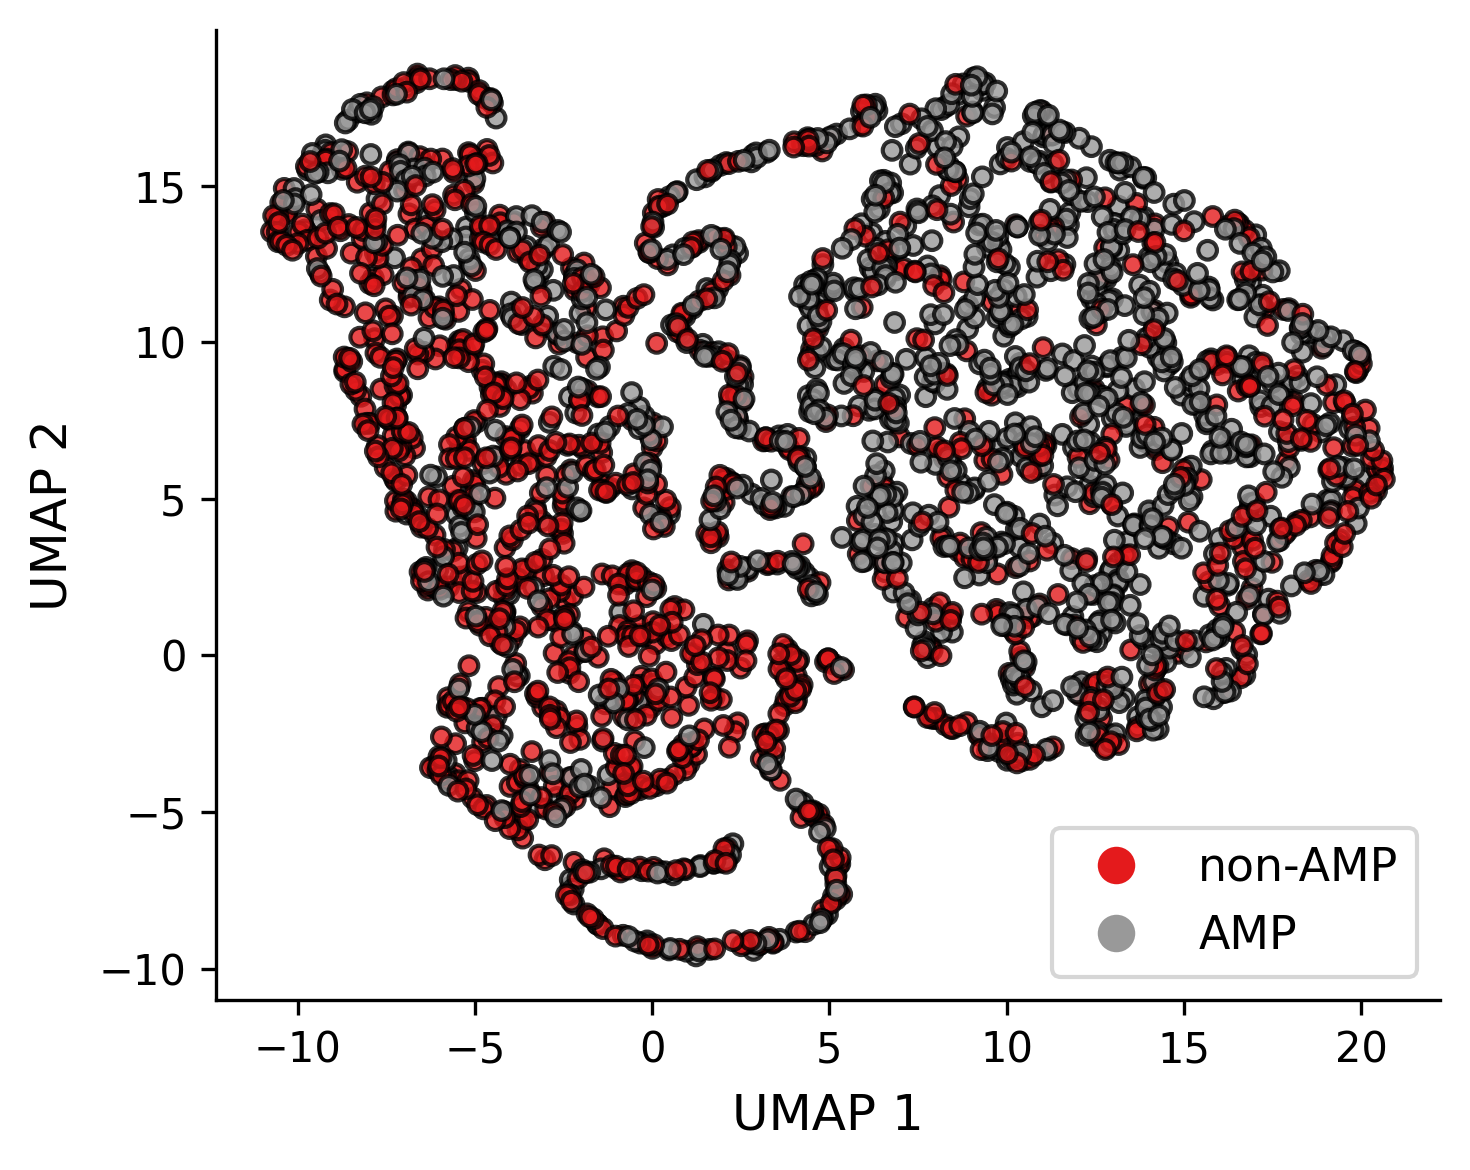

In [8]:
# AMP labels
unique_labels = np.unique(y)
label_names = ['non-AMP', 'AMP']

# 2D UMAP plot
plt.figure(figsize=(5, 4), dpi=300)
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=y, cmap='Set1', s=20, edgecolor='k', alpha=0.8)

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(i / (len(unique_labels) - 1)), markersize=10, label=label_names[i])
           for i in unique_labels]
plt.legend(handles=handles, fontsize=11, loc='best')

# Set coordinate labels
plt.xlabel('UMAP 1', fontsize=12, labelpad=5)
plt.ylabel('UMAP 2', fontsize=12, labelpad=5)

# Clean up the plot
plt.grid(False)
sns.despine()
plt.tight_layout()

# Save the plot 
# plt.savefig('Eco_UMAP.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Split dataset into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.15, stratify=y,
                                                   random_state=random_state)

print("Size of training set: {}   size of test set:"
      " {}\n".format(X_train.shape[0], X_test.shape[0]))

<IPython.core.display.Javascript object>

Size of training set: 2254   size of test set: 398



#**Logit**

In [10]:
# Performing Bayesian search to optimize parameters for logit
logit = LogisticRegression(max_iter=5000, random_state=random_state)

param = {'C': (1e-1,1e2, 'log-uniform')} 

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
logit_cv = BayesSearchCV(estimator=logit, search_spaces=param, cv=cv, scoring='roc_auc', 
                         n_jobs=-1, random_state=random_state)

start_time = time.time()
logit_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', logit_cv.best_params_)
print('best score after search cv:', logit_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('C', 27.364528220782454)])
best score after search cv: 0.8843653854759854
time taken: 0:01:19.722450


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

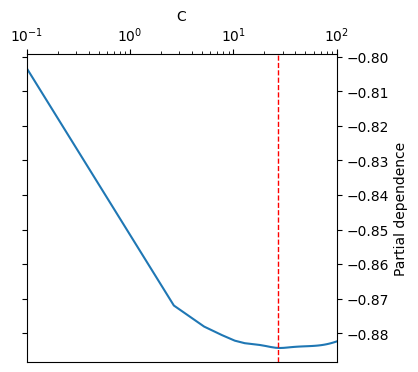

In [11]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(4, 4))
plot_objective(logit_cv.optimizer_results_[0], ax=ax)
plt.show()

In [12]:
# Train logit
logit_tuned = LogisticRegression(**logit_cv.best_params_, max_iter=5000,
                                 n_jobs=-1, random_state=random_state)

logit_tuned.fit(X_train, y_train)

<IPython.core.display.Javascript object>

LogisticRegression(C=27.364528220782454, max_iter=5000, n_jobs=-1,
                   random_state=42)

In [13]:
# Print intercept & coefficients
print('intercept:', logit_tuned.intercept_)
print('coef:', logit_tuned.coef_, end='\n')

intercept: [-0.55382058]
coef: [[ 4.60581728  7.26654619  2.84280387 ... -3.85622275  1.77119135
  -2.20385994]]


In [14]:
# Evaluate the logit model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(logit_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the logit model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the logit model on the training set:
Acc: 0.8164
Pr: 0.7921
Sn: 0.8355
F1: 0.8152
MCC: 0.6364
AUROC: 0.8847


In [15]:
# Evaluate the logit model on the test set
y_pred_logit = logit_tuned.predict(X_test)
y_proba_logit = logit_tuned.predict_proba(X_test)[:, 1]

print("Performance of the logit model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_logit)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_logit)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_logit)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_logit)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_logit)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_logit)))

Performance of the logit model on the test set:
Acc: 0.8015
Pr: 0.7727
Sn: 0.8543
F1: 0.8115
MCC: 0.6064
AUROC: 0.8731


#**KNN**

In [16]:
# Performing Bayesian search to optimize parameters for KNN
knn = KNeighborsClassifier()

param = {'n_neighbors': (3,20),
         'weights': ['distance', 'uniform'],
         'p': (1,2,3),
         'metric': ['minkowski', 'manhattan', 'euclidean']
         }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
knn_cv = BayesSearchCV(estimator=knn, search_spaces=param, cv=cv, scoring='roc_auc', 
                       n_jobs=-1, random_state=random_state)

start_time = time.time()
knn_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', knn_cv.best_params_)
print('best score after search cv:', knn_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('metric', 'minkowski'), ('n_neighbors', 6), ('p', 1), ('weights', 'distance')])
best score after search cv: 0.8995761218576239
time taken: 0:01:04.761267


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

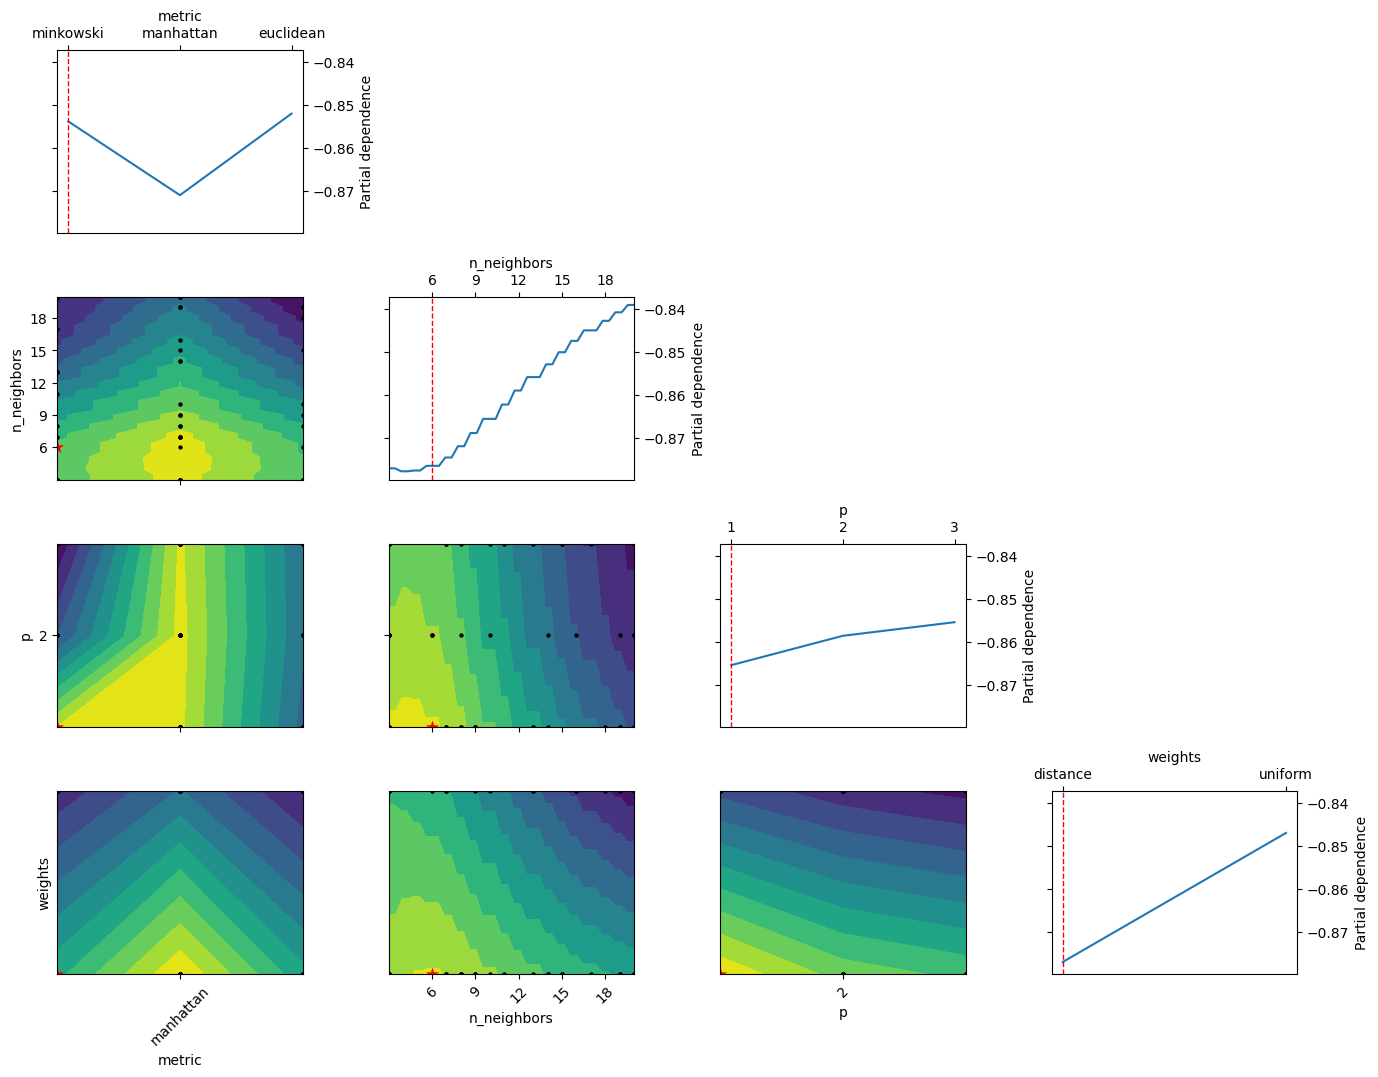

In [17]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(16, 12))
plot_objective(knn_cv.optimizer_results_[0], ax=ax)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

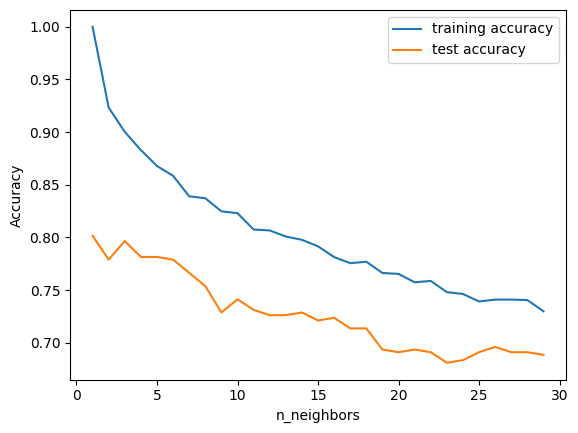

In [18]:
# Find the optimum k
train_acc = []
test_acc = []

# try n_neighbors from 1 to 30
neighbors_settings = range(1, 30)

for n_neighbors in neighbors_settings:
    # build the model
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    
    # record training set accuracy
    train_acc.append(knn.score(X_train, y_train))
    
    # record generalization accuracy
    test_acc.append(knn.score(X_test, y_test))

plt.plot(neighbors_settings, train_acc, label="training accuracy")
plt.plot(neighbors_settings, test_acc, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [19]:
# Train KNN
knn_tuned = KNeighborsClassifier(**knn_cv.best_params_, n_jobs=-1)

knn_tuned.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=6, p=1, weights='distance')

In [20]:
# Evaluate the KNN model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(knn_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the KNN model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the KNN model on the training set:
Acc: 0.8315
Pr: 0.8108
Sn: 0.8622
F1: 0.8360
MCC: 0.6644
AUROC: 0.9052


In [21]:
# Evaluate the KNN model on the test set
y_pred_knn = knn_tuned.predict(X_test)
y_proba_knn = knn_tuned.predict_proba(X_test)[:, 1]

print("Performance of the KNN model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_knn)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_knn)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_knn)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_knn)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_knn)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_knn)))

Performance of the KNN model on the test set:
Acc: 0.7940
Pr: 0.7696
Sn: 0.8392
F1: 0.8029
MCC: 0.5904
AUROC: 0.8786


#**SVC linear**

In [22]:
# Performing Bayesian search to optimize parameters for SVC lin
svc = SVC(random_state=random_state, kernel='linear')

param = {'C': (1e-2,20, 'log-uniform')}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
svc_cv = BayesSearchCV(estimator=svc, search_spaces=param, cv=cv, scoring='roc_auc', 
                       n_jobs=-1, random_state=random_state)

start_time = time.time()
svc_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', svc_cv.best_params_)
print('best score after search cv:', svc_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('C', 6.8973029293873145)])
best score after search cv: 0.8808801030397279
time taken: 0:04:42.326940


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

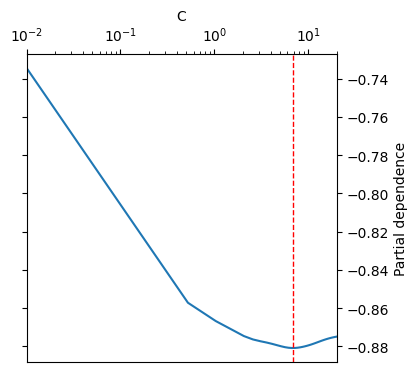

In [23]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(4, 4))
plot_objective(svc_cv.optimizer_results_[0], ax=ax)
plt.show()

In [24]:
# Train SVC lin
svc_lin = SVC(kernel='linear', **svc_cv.best_params_, 
              probability=True, random_state=random_state)

svc_lin.fit(X_train, y_train)

SVC(C=6.8973029293873145, kernel='linear', probability=True, random_state=42)

In [25]:
# Evaluate the SVC sig model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(svc_lin, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the SVC model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the SVC model on the training set:
Acc: 0.8027
Pr: 0.7811
Sn: 0.8407
F1: 0.8126
MCC: 0.6087
AUROC: 0.8786


In [26]:
# Evaluate the SVC lin model on the test set
y_pred_svc = svc_lin.predict(X_test)
y_proba_svc = svc_lin.predict_proba(X_test)[:, 1]

print("Performance of the SVC model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_svc)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_svc)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_svc)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_svc)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_svc)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_svc)))

Performance of the SVC model on the test set:
Acc: 0.7915
Pr: 0.7589
Sn: 0.8543
F1: 0.8038
MCC: 0.5876
AUROC: 0.8740


#**SVC sigmoid**

In [27]:
# Performing Bayesian search to optimize parameters for SVC sig
svc = SVC(random_state=random_state, kernel='sigmoid', coef0=-5)

param = {'C': (1e4,1e5, 'log-uniform'), 
         'gamma': (5e-1,1, 'log-uniform')
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
svc_cv = BayesSearchCV(estimator=svc, search_spaces=param, cv=cv, scoring='roc_auc', 
                       n_jobs=-1, random_state=random_state)

start_time = time.time()
svc_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', svc_cv.best_params_)
print('best score after search cv:', svc_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('C', 27530.386488456363), ('gamma', 1.0)])
best score after search cv: 0.921913842677019
time taken: 0:04:52.483425


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

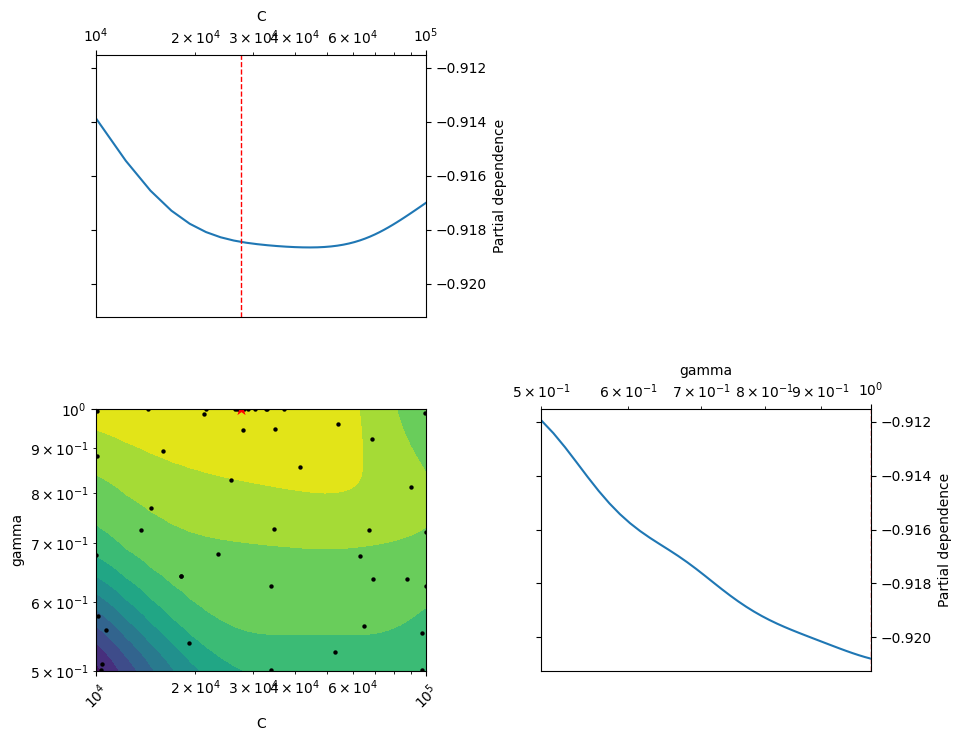

In [28]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(svc_cv.optimizer_results_[0], ax=ax)
plt.show()

In [29]:
# Train SVC sig
svc_sig = SVC(kernel='sigmoid', coef0=-5, **svc_cv.best_params_, 
              probability=True, random_state=random_state)

svc_sig.fit(X_train, y_train)

SVC(C=27530.386488456363, coef0=-5, gamma=1.0, kernel='sigmoid',
    probability=True, random_state=42)

In [30]:
# Evaluate the SVC sig model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(svc_sig, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the SVC model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the SVC model on the training set:
Acc: 0.8559
Pr: 0.8542
Sn: 0.8628
F1: 0.8595
MCC: 0.7142
AUROC: 0.9245


In [31]:
# Evaluate the SVC sig model on the test set
y_pred_svc = svc_sig.predict(X_test)
y_proba_svc = svc_sig.predict_proba(X_test)[:, 1]

print("Performance of the SVC model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_svc)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_svc)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_svc)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_svc)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_svc)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_svc)))

Performance of the SVC model on the test set:
Acc: 0.8442
Pr: 0.8246
Sn: 0.8744
F1: 0.8488
MCC: 0.6897
AUROC: 0.9180


#**SVC rbf**

In [32]:
# Performing Bayesian search to optimize parameters for SVC rbf
svc = SVC(random_state=random_state, kernel='rbf')

param = {'C': (1e-1,1e2, 'log-uniform'), 
         'gamma': (1e-2,1e1,'log-uniform')}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
svc_cv = BayesSearchCV(estimator=svc, search_spaces=param, cv=cv, scoring='roc_auc', 
                       n_jobs=-1, random_state=random_state)

start_time = time.time()
svc_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', svc_cv.best_params_)
print('best score after search cv:', svc_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('C', 6.850271557587302), ('gamma', 1.862076383200795)])
best score after search cv: 0.9252726329391496
time taken: 0:06:03.033692


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

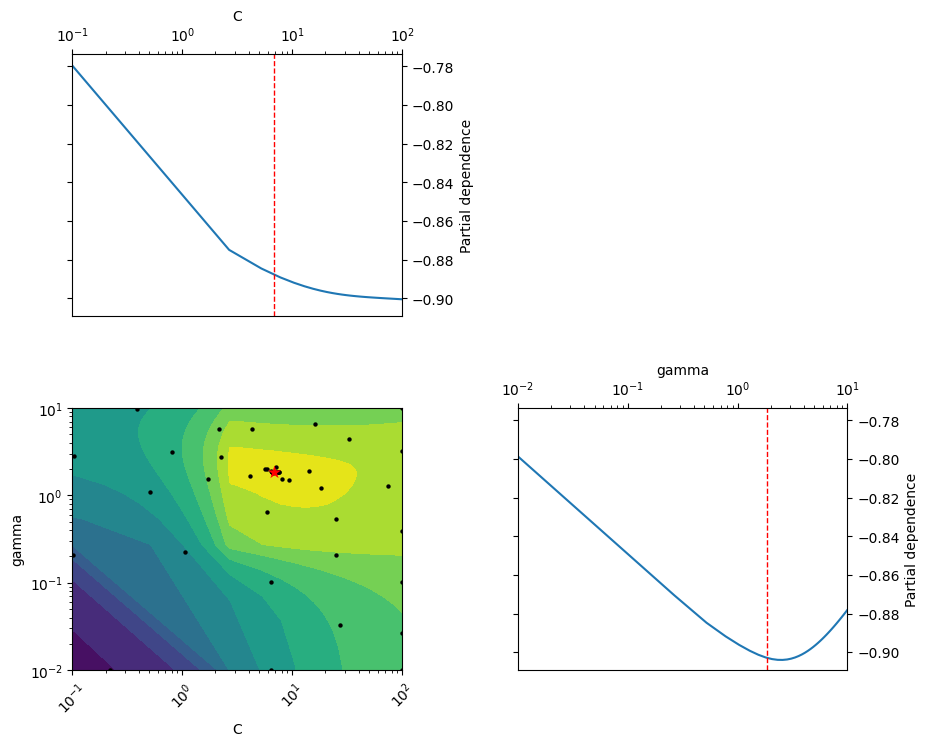

In [33]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(svc_cv.optimizer_results_[0], ax=ax)
plt.show()

In [34]:
# Train SVC rbf
svc_rbf = SVC(kernel='rbf', **svc_cv.best_params_, 
              probability=True, random_state=random_state)

svc_rbf.fit(X_train, y_train)

SVC(C=6.850271557587302, gamma=1.862076383200795, probability=True,
    random_state=42)

In [35]:
# Evaluate the SVC rbf model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(svc_rbf, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the SVC model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the SVC model on the training set:
Acc: 0.8581
Pr: 0.8468
Sn: 0.8705
F1: 0.8644
MCC: 0.7190
AUROC: 0.9263


In [36]:
# Evaluate the SVC rbf model on the test set
y_pred_svc = svc_rbf.predict(X_test)
y_proba_svc = svc_rbf.predict_proba(X_test)[:, 1]

print("Performance of the SVC model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_svc)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_svc)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_svc)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_svc)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_svc)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_svc)))

Performance of the SVC model on the test set:
Acc: 0.8593
Pr: 0.8454
Sn: 0.8794
F1: 0.8621
MCC: 0.7192
AUROC: 0.9232


#**RF**

In [37]:
# Performing Bayesian search to optimize parameters for RF
rf = RandomForestClassifier(criterion='entropy', max_features='sqrt',
                            min_samples_split=2, min_samples_leaf=1,
                            random_state=random_state)

param = {'n_estimators': (30,800), 
         'max_depth': (10,40)
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
rf_cv = BayesSearchCV(estimator=rf, search_spaces=param, cv=cv, scoring='roc_auc', 
                          n_jobs=-1, random_state=random_state)

start_time = time.time()
rf_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', rf_cv.best_params_)
print('best score after search cv:', rf_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('max_depth', 26), ('n_estimators', 623)])
best score after search cv: 0.9277289864963137
time taken: 0:04:45.186942


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

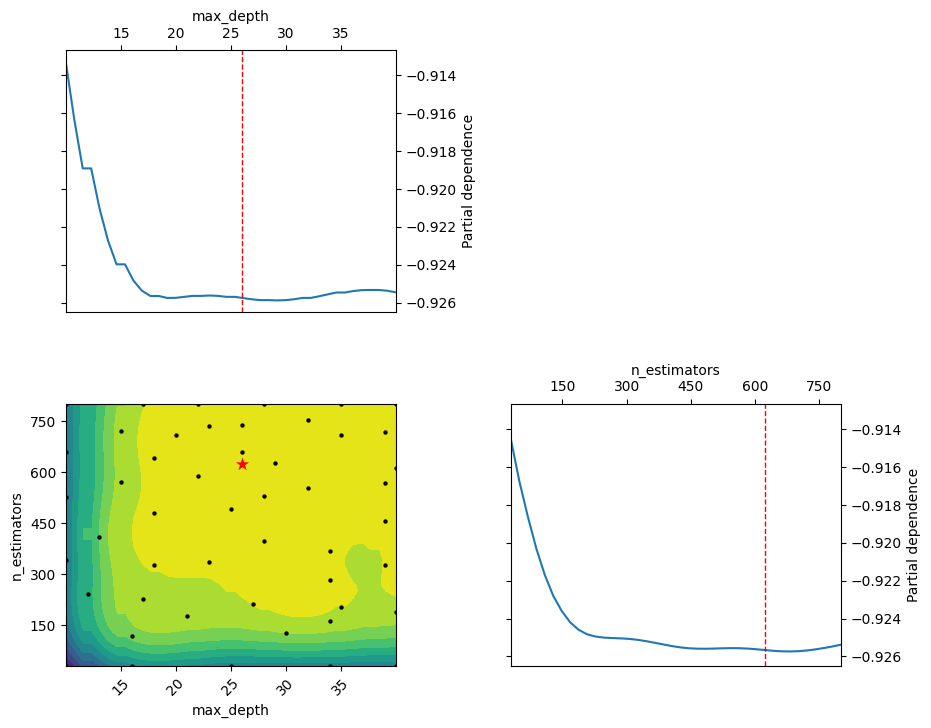

In [38]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(rf_cv.optimizer_results_[0], ax=ax)
plt.show()

In [39]:
# Train RF 
rf_tuned = RandomForestClassifier(**rf_cv.best_params_, criterion='entropy', 
                                  max_features='sqrt', min_samples_split=2, 
                                  min_samples_leaf=1, n_jobs=-1, 
                                  random_state=random_state)

rf_tuned.fit(X_train, y_train)

<IPython.core.display.Javascript object>

RandomForestClassifier(criterion='entropy', max_depth=26, n_estimators=623,
                       n_jobs=-1, random_state=42)

In [40]:
# Evaluate the RF model on the training set 
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(rf_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the RF model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the RF model on the training set:
Acc: 0.8489
Pr: 0.8396
Sn: 0.8584
F1: 0.8541
MCC: 0.6993
AUROC: 0.9286


In [41]:
# Evaluate the RF model on the test set
y_pred_rf = rf_tuned.predict(X_test)
y_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]

print("Performance of the RF model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_rf)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_rf)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_rf)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_rf)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_rf)))

Performance of the RF model on the test set:
Acc: 0.8518
Pr: 0.8608
Sn: 0.8392
F1: 0.8499
MCC: 0.7037
AUROC: 0.9159


#**XGB**

In [42]:
# Performing Bayesian search to optimize parameters for XGB
xgb = XGBClassifier(tree_method='gpu_hist', gpu_id=0, objective='binary:logistic', 
                    max_depth=17, subsample=0.8, min_child_weight=1, colsample_bytree=1, 
                    reg_lambda=1, random_state=random_state)

param = {'learning_rate': (1e-2,4e-1, 'log-uniform'),
         'n_estimators': (300,800)
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
xgb_cv = BayesSearchCV(estimator=xgb, search_spaces=param, cv=10, scoring='roc_auc',
                      random_state=random_state)

start_time = time.time()
xgb_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best paremeters: ', xgb_cv.best_params_)
print('best score after search cv:', xgb_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best paremeters:  OrderedDict([('learning_rate', 0.03467248868073228), ('n_estimators', 614)])
best score after search cv: 0.9378950695322377
time taken: 0:42:57.038958


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

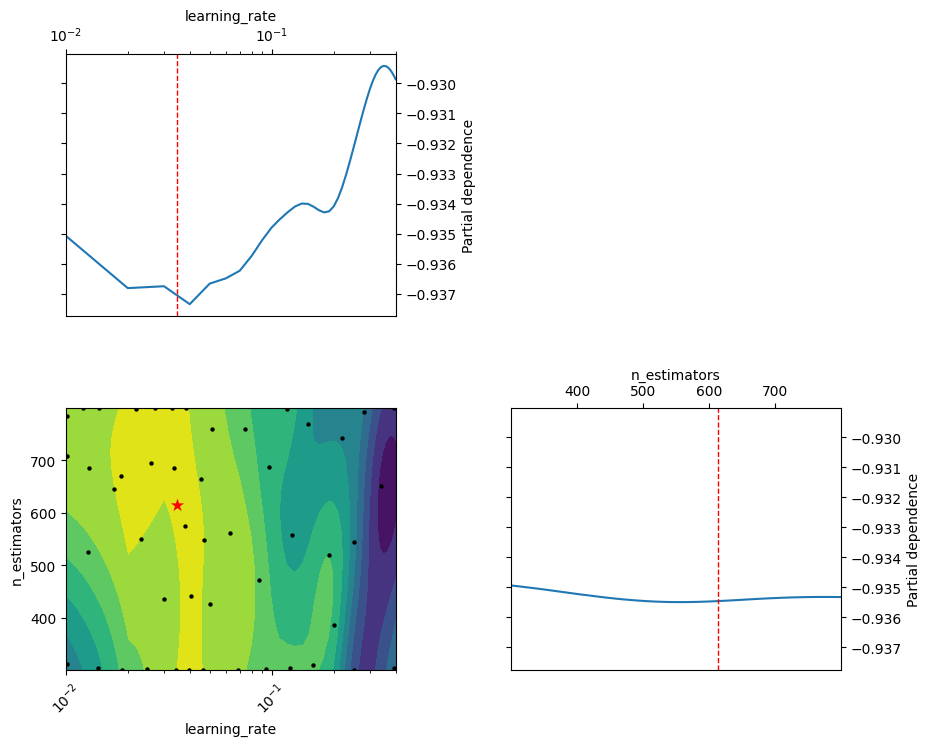

In [43]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(xgb_cv.optimizer_results_[0], ax=ax)
plt.show()

In [44]:
# Train XGB
xgb_tuned = XGBClassifier(**xgb_cv.best_params_, tree_method='gpu_hist', 
                          gpu_id=0, objective='binary:logistic', max_depth=17, 
                          subsample=0.8, min_child_weight=1, colsample_bytree=1, 
                          reg_lambda=1, random_state=random_state)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None, gpu_id=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03467248868073228,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=17, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              n_estimators=614, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [45]:
# Evaluate the XGB model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(xgb_tuned, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the XGB model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the XGB model on the training set:
Acc: 0.8600
Pr: 0.8526
Sn: 0.8850
F1: 0.8616
MCC: 0.7224
AUROC: 0.9332


In [46]:
# Evaluate the XGB model on the test set
y_pred_xgb = xgb_tuned.predict(X_test)
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

print("Performance of the XGB model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_xgb)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_xgb)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_xgb)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_xgb)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_xgb)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_xgb)))

Performance of the XGB model on the test set:
Acc: 0.8794
Pr: 0.8794
Sn: 0.8794
F1: 0.8794
MCC: 0.7588
AUROC: 0.9327


#**LGBM**

In [62]:
# Performing Bayesian search to optimize parameters for LGBM
lgbm = LGBMClassifier(device='gpu', objective='binary', extra_trees=True, verbose=-1, 
                      max_depth=12, min_data_in_leaf=3, bagging_fraction=1.0, 
                      feature_fraction=1.0, reg_lambda=1e-3, num_leaves=84, 
                      random_state=random_state)

param = {'n_estimators': (840, 900),
         'learning_rate': (5e-3,1e-1,'log-uniform'),
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
lgbm_cv = BayesSearchCV(estimator=lgbm, search_spaces=param, cv=cv, scoring='roc_auc',
                       random_state=random_state)

start_time = time.time()
lgbm_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', lgbm_cv.best_params_)
print('best score after search cv:', lgbm_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('learning_rate', 0.015153789891045799), ('n_estimators', 867)])
best score after search cv: 0.9338381599409284
time taken: 1:23:13.628999


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

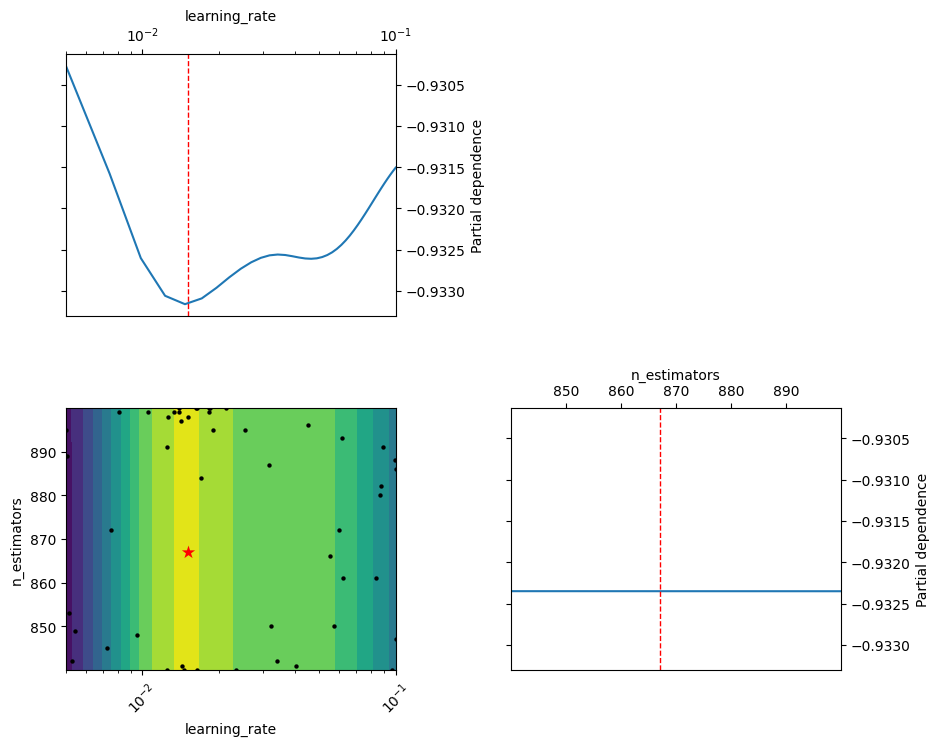

In [63]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(lgbm_cv.optimizer_results_[0], ax=ax)
plt.show()

In [64]:
# Train LGBM 
lgbm_tuned = LGBMClassifier(**lgbm_cv.best_params_, device='gpu', 
                            objective='binary', extra_trees=True,
                            verbose=-1, max_depth=12, min_data_in_leaf=3, 
                            bagging_fraction=1.0, feature_fraction=1.0, 
                            reg_lambda=1e-3, num_leaves=84, 
                            random_state=random_state)

lgbm_tuned.fit(X_train, y_train)

LGBMClassifier(bagging_fraction=1.0, device='gpu', extra_trees=True,
               feature_fraction=1.0, learning_rate=0.015153789891045799,
               max_depth=12, min_data_in_leaf=3, n_estimators=867,
               num_leaves=84, objective='binary', random_state=42,
               reg_lambda=0.001, verbose=-1)

In [65]:
# Evaluate the LGBM model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(lgbm_tuned, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the LGBM model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the LGBM model on the training set:
Acc: 0.8559
Pr: 0.8497
Sn: 0.8800
F1: 0.8606
MCC: 0.7145
AUROC: 0.9349


In [66]:
# Evaluate the LGBM model on the test set
y_pred_lgbm = lgbm_tuned.predict(X_test)
y_proba_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]

print("Performance of the LGBM model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_lgbm)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_lgbm)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_lgbm)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_lgbm)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_lgbm)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_lgbm)))

Performance of the LGBM model on the test set:
Acc: 0.8693
Pr: 0.8769
Sn: 0.8593
F1: 0.8680
MCC: 0.7388
AUROC: 0.9356


In [67]:
# Save the LGBM model
joblib.dump(lgbm_tuned, "model/lgbm.pkl")

['model/lgbm.pkl']

#**Dforest**

In [54]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Performing Bayesian search to optimize parameters for deepforest
dforest = CascadeForestClassifier(use_predictor=True, predictor='forest', 
                                  criterion='entropy', min_samples_split=2, 
                                  min_samples_leaf=1, n_jobs=-1, 
                                  n_tolerant_rounds=5, verbose=0, 
                                  random_state=random_state)

param = {'n_estimators': (4,8), 
         'n_trees': (300,450),
         'max_depth': (5,30), 
         }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
dforest_cv = BayesSearchCV(estimator=dforest, search_spaces=param, cv=cv, 
                           n_jobs=-1, verbose=0, random_state=random_state)

start_time = time.time()
dforest_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

# Print best parameters
print('best parameters: ', dforest_cv.best_params_)
print('best score after search cv:', dforest_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

The objective has been evaluated at point [21, 4, 302] before, using random point [18, 5, 362]


best parameters:  OrderedDict([('max_depth', 27), ('n_estimators', 4), ('n_trees', 302)])
best score after search cv: 0.8620334316617502
time taken: 2:03:21.728392


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

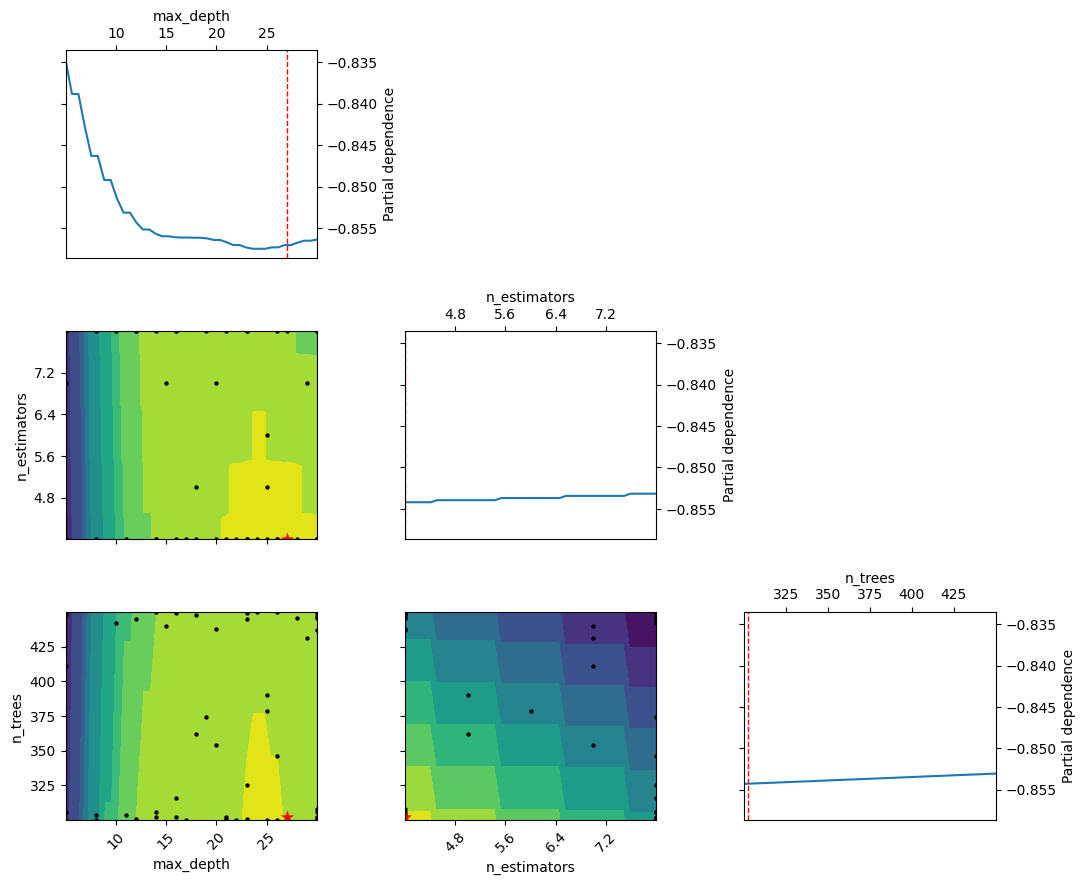

In [55]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(12, 10))
plot_objective(dforest_cv.optimizer_results_[0], ax=ax)
plt.show()

In [56]:
# Train deepforest model
dforest_tuned = CascadeForestClassifier(**dforest_cv.best_params_, use_predictor=True, 
                                        predictor='forest', criterion='entropy', 
                                        min_samples_split=2, min_samples_leaf=1, 
                                        n_tolerant_rounds=5, n_jobs=-1, 
                                        random_state=random_state)

dforest_tuned.fit(X_train, y_train)

[2024-09-05 00:06:58.208] Start to fit the model:
[2024-09-05 00:06:58.208] Fitting cascade layer = 0 
[2024-09-05 00:07:01.175] layer = 0  | Val Acc = 85.980 % | Elapsed = 2.967 s
[2024-09-05 00:07:01.185] Fitting cascade layer = 1 
[2024-09-05 00:07:03.692] layer = 1  | Val Acc = 85.759 % | Elapsed = 2.507 s
[2024-09-05 00:07:03.692] Early stopping counter: 1 out of 5
[2024-09-05 00:07:03.699] Fitting cascade layer = 2 
[2024-09-05 00:07:06.147] layer = 2  | Val Acc = 84.960 % | Elapsed = 2.448 s
[2024-09-05 00:07:06.147] Early stopping counter: 2 out of 5
[2024-09-05 00:07:06.159] Fitting cascade layer = 3 
[2024-09-05 00:07:08.570] layer = 3  | Val Acc = 84.339 % | Elapsed = 2.411 s
[2024-09-05 00:07:08.570] Early stopping counter: 3 out of 5
[2024-09-05 00:07:08.578] Fitting cascade layer = 4 
[2024-09-05 00:07:11.032] layer = 4  | Val Acc = 83.673 % | Elapsed = 2.454 s
[2024-09-05 00:07:11.032] Early stopping counter: 4 out of 5
[2024-09-05 00:07:11.041] Fitting cascade layer = 5

In [57]:
# Evaluate the deepforest model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(dforest_tuned, X_train, y_train, cv=10, verbose=0, scoring=scoring)

print("Performance of the deepforest model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

[2024-09-05 00:07:13.908] Start to fit the model:
[2024-09-05 00:07:13.908] Fitting cascade layer = 0 
[2024-09-05 00:07:16.632] layer = 0  | Val Acc = 86.193 % | Elapsed = 2.724 s
[2024-09-05 00:07:16.642] Fitting cascade layer = 1 
[2024-09-05 00:07:18.881] layer = 1  | Val Acc = 86.341 % | Elapsed = 2.239 s
[2024-09-05 00:07:18.888] Fitting cascade layer = 2 
[2024-09-05 00:07:21.205] layer = 2  | Val Acc = 85.750 % | Elapsed = 2.317 s
[2024-09-05 00:07:21.205] Early stopping counter: 1 out of 5
[2024-09-05 00:07:21.211] Fitting cascade layer = 3 
[2024-09-05 00:07:23.504] layer = 3  | Val Acc = 84.813 % | Elapsed = 2.293 s
[2024-09-05 00:07:23.504] Early stopping counter: 2 out of 5
[2024-09-05 00:07:23.511] Fitting cascade layer = 4 
[2024-09-05 00:07:25.747] layer = 4  | Val Acc = 84.320 % | Elapsed = 2.236 s
[2024-09-05 00:07:25.747] Early stopping counter: 3 out of 5
[2024-09-05 00:07:25.756] Fitting cascade layer = 5 
[2024-09-05 00:07:28.110] layer = 5  | Val Acc = 84.270 % |

Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 76, in _cached_call
    return cache[method]
KeyError: 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 373, in _score
    y_pred = method_caller(clf, "decision_function", X)
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 78, in _cached_call
    result = getattr(estimator, method)(*args, **kwargs)
AttributeError: 'CascadeForestClassifier' object has no attribute 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home

[2024-09-05 00:07:33.283] Start to fit the model:
[2024-09-05 00:07:33.283] Fitting cascade layer = 0 
[2024-09-05 00:07:36.128] layer = 0  | Val Acc = 85.552 % | Elapsed = 2.845 s
[2024-09-05 00:07:36.138] Fitting cascade layer = 1 
[2024-09-05 00:07:38.465] layer = 1  | Val Acc = 85.799 % | Elapsed = 2.328 s
[2024-09-05 00:07:38.477] Fitting cascade layer = 2 
[2024-09-05 00:07:40.668] layer = 2  | Val Acc = 85.602 % | Elapsed = 2.191 s
[2024-09-05 00:07:40.669] Early stopping counter: 1 out of 5
[2024-09-05 00:07:40.677] Fitting cascade layer = 3 
[2024-09-05 00:07:43.034] layer = 3  | Val Acc = 85.010 % | Elapsed = 2.357 s
[2024-09-05 00:07:43.034] Early stopping counter: 2 out of 5
[2024-09-05 00:07:43.041] Fitting cascade layer = 4 
[2024-09-05 00:07:45.392] layer = 4  | Val Acc = 84.270 % | Elapsed = 2.351 s
[2024-09-05 00:07:45.393] Early stopping counter: 3 out of 5
[2024-09-05 00:07:45.404] Fitting cascade layer = 5 
[2024-09-05 00:07:47.886] layer = 5  | Val Acc = 84.467 % |

Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 76, in _cached_call
    return cache[method]
KeyError: 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 373, in _score
    y_pred = method_caller(clf, "decision_function", X)
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 78, in _cached_call
    result = getattr(estimator, method)(*args, **kwargs)
AttributeError: 'CascadeForestClassifier' object has no attribute 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home

[2024-09-05 00:07:53.212] Start to fit the model:
[2024-09-05 00:07:53.212] Fitting cascade layer = 0 
[2024-09-05 00:07:56.053] layer = 0  | Val Acc = 84.813 % | Elapsed = 2.841 s
[2024-09-05 00:07:56.061] Fitting cascade layer = 1 
[2024-09-05 00:07:58.456] layer = 1  | Val Acc = 84.763 % | Elapsed = 2.395 s
[2024-09-05 00:07:58.456] Early stopping counter: 1 out of 5
[2024-09-05 00:07:58.466] Fitting cascade layer = 2 
[2024-09-05 00:08:00.928] layer = 2  | Val Acc = 84.418 % | Elapsed = 2.462 s
[2024-09-05 00:08:00.928] Early stopping counter: 2 out of 5
[2024-09-05 00:08:00.938] Fitting cascade layer = 3 
[2024-09-05 00:08:03.316] layer = 3  | Val Acc = 84.073 % | Elapsed = 2.378 s
[2024-09-05 00:08:03.316] Early stopping counter: 3 out of 5
[2024-09-05 00:08:03.326] Fitting cascade layer = 4 
[2024-09-05 00:08:05.837] layer = 4  | Val Acc = 83.925 % | Elapsed = 2.511 s
[2024-09-05 00:08:05.837] Early stopping counter: 4 out of 5
[2024-09-05 00:08:05.844] Fitting cascade layer = 5

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the deepforest model on the training set:
Acc: 0.8556
Pr: 0.8485
Sn: 0.8711
F1: 0.8590
MCC: 0.7113
AUROC: nan


In [58]:
# Evaluate the deepforest model on the test set
y_pred_dforest = dforest_tuned.predict(X_test)
y_proba_dforest = dforest_tuned.predict_proba(X_test)[:, 1]

print("Performance of the deepforest model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_dforest)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_dforest)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_dforest)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_dforest)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_dforest)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_dforest)))

[2024-09-05 00:10:08.935] Start to evalute the model:
[2024-09-05 00:10:08.940] Evaluating cascade layer = 0 
[2024-09-05 00:10:09.691] Evaluating the predictor
[2024-09-05 00:10:09.800] Start to evalute the model:
[2024-09-05 00:10:09.807] Evaluating cascade layer = 0 
[2024-09-05 00:10:10.511] Evaluating the predictor
Performance of the deepforest model on the test set:
Acc: 0.8593
Pr: 0.8705
Sn: 0.8442
F1: 0.8571
MCC: 0.7189
AUROC: 0.9250


In [59]:
# Save the dforest model
joblib.dump(dforest_tuned, "model/dforest.pkl")

['model/dforest.pkl']

#**Vote**

In [68]:
# Train vote model 
vote = VotingClassifier(estimators=[('logit', logit_tuned), ('svc_sig', svc_sig), 
                                    ('rf', rf_tuned)], voting='soft') 
                                          
vote.fit(X_train, y_train)

VotingClassifier(estimators=[('logit',
                              LogisticRegression(C=27.364528220782454,
                                                 max_iter=5000, n_jobs=-1,
                                                 random_state=42)),
                             ('svc_sig',
                              SVC(C=27530.386488456363, coef0=-5, gamma=1.0,
                                  kernel='sigmoid', probability=True,
                                  random_state=42)),
                             ('rf',
                              RandomForestClassifier(criterion='entropy',
                                                     max_depth=26,
                                                     n_estimators=623,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 voting='soft')

In [69]:
## Evaluate the vote model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(vote, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the vote model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the vote model on the training set:
Acc: 0.8533
Pr: 0.8502
Sn: 0.8667
F1: 0.8577
MCC: 0.7083
AUROC: 0.9293


In [70]:
# Evaluate the vote model on the test set
y_pred_vote = vote.predict(X_test)
y_proba_vote = vote.predict_proba(X_test)[:, 1]

print("Performance of the vote model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_vote)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_vote)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_vote)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_vote)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_vote)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_vote)))

Performance of the vote model on the test set:
Acc: 0.8568
Pr: 0.8447
Sn: 0.8744
F1: 0.8593
MCC: 0.7140
AUROC: 0.9204


In [71]:
# Save the model
joblib.dump(vote, "model/vote_lssr.pkl")

['model/vote_lssr.pkl']

#**Stack**

In [74]:
# Performing Bayesian search to optimize parameters for stack final estimator
param = {'final_estimator__C': (1e-1,1e2,'log-uniform')} 

stack = StackingClassifier(estimators=[('logit', logit_tuned), ('svc_sig', svc_sig),
                                      ('rf', rf_tuned)], final_estimator=LogisticRegression(max_iter=100, 
                                        penalty='l2', solver='lbfgs'), cv=5, n_jobs=-1)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
stack_cv = BayesSearchCV(estimator=stack, search_spaces=param, cv=cv, scoring='roc_auc',
                        n_jobs=-1, random_state=random_state)

start_time = time.time()
stack_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best paremeters: ', stack_cv.best_params_)
print('best estimator: ', stack_cv.best_estimator_)
print('best score after search cv:', stack_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best paremeters:  OrderedDict([('final_estimator__C', 1.0299308617106977)])
best estimator:  StackingClassifier(cv=5,
                   estimators=[('logit',
                                LogisticRegression(C=27.364528220782454,
                                                   max_iter=5000, n_jobs=-1,
                                                   random_state=42)),
                               ('svc_sig',
                                SVC(C=27530.386488456363, coef0=-5, gamma=1.0,
                                    kernel='sigmoid', probability=True,
                                    random_state=42)),
                               ('rf',
                                RandomForestClassifier(criterion='entropy',
                                                       max_depth=26,
                                                       n_estimators=623,
                                                       n_jobs=-1,
                                                  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

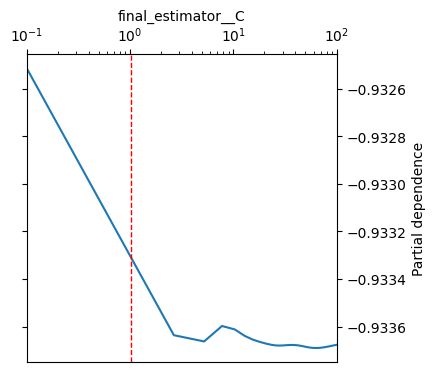

In [75]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(4, 4))
plot_objective(stack_cv.optimizer_results_[0], ax=ax)
plt.show()

In [76]:
# Train stack model 
stack = StackingClassifier(estimators=[('logit', logit_tuned), ('svc_sig', svc_sig), 
                                       ('rf', rf_tuned)], final_estimator=LogisticRegression(max_iter=100, 
                                        C=1.0299, penalty='l2', solver='lbfgs'), cv=5, n_jobs=-1) 
                                          
stack.fit(X_train, y_train)

<IPython.core.display.Javascript object>

StackingClassifier(cv=5,
                   estimators=[('logit',
                                LogisticRegression(C=27.364528220782454,
                                                   max_iter=5000, n_jobs=-1,
                                                   random_state=42)),
                               ('svc_sig',
                                SVC(C=27530.386488456363, coef0=-5, gamma=1.0,
                                    kernel='sigmoid', probability=True,
                                    random_state=42)),
                               ('rf',
                                RandomForestClassifier(criterion='entropy',
                                                       max_depth=26,
                                                       n_estimators=623,
                                                       n_jobs=-1,
                                                       random_state=42))],
                   final_estimator=LogisticRegression(C=1.0299), n_jobs=-1)

In [77]:
# Evaluate the stack model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(stack, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the stack model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the stack model on the training set:
Acc: 0.8603
Pr: 0.8632
Sn: 0.8661
F1: 0.8632
MCC: 0.7218
AUROC: 0.9347


In [78]:
# Evaluate the stack model on the test set
y_pred_stack = stack.predict(X_test)
y_proba_stack = stack.predict_proba(X_test)[:, 1]

print("Performance the stack model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_stack)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_stack)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_stack)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_stack)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_stack)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_stack)))

Performance the stack model on the test set:
Acc: 0.8543
Pr: 0.8473
Sn: 0.8643
F1: 0.8557
MCC: 0.7087
AUROC: 0.9269


In [79]:
# Save the model
joblib.dump(stack, "model/stack_lssr.pkl")

['model/stack_lssr.pkl']

#**PR curves**

[2024-09-05 07:48:02.236] Start to evalute the model:
[2024-09-05 07:48:02.241] Evaluating cascade layer = 0 
[2024-09-05 07:48:02.849] Evaluating the predictor


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

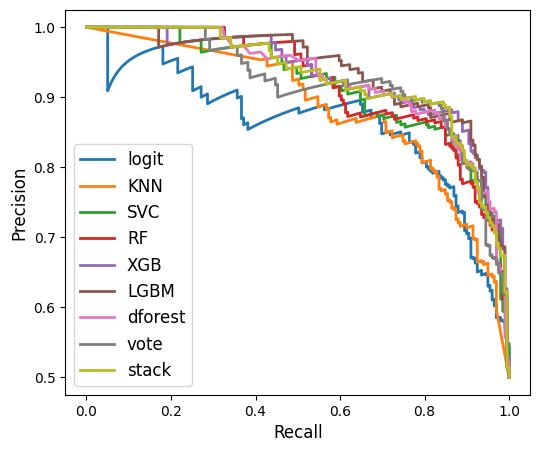

In [80]:
# Calculate decision function or probabilities for each model
y_thres_logit = logit_tuned.decision_function(X_test)
y_proba_knn = knn_tuned.predict_proba(X_test)[:, 1]
y_thres_svc = svc_sig.decision_function(X_test)
y_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
y_proba_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]
y_proba_dforest = dforest_tuned.predict_proba(X_test)[:, 1]
y_proba_vote = vote.predict_proba(X_test)[:, 1]
y_proba_stack = stack.predict_proba(X_test)[:, 1]

# Calculate precision and recall for each model
precision_logit, recall_logit, _ = precision_recall_curve(y_test, y_thres_logit)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_proba_knn)
precision_svc, recall_svc, _ = precision_recall_curve(y_test, y_thres_svc)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_proba_lgbm)
precision_dforest, recall_dforest, _ = precision_recall_curve(y_test, y_proba_dforest)
precision_vote, recall_vote, _ = precision_recall_curve(y_test, y_proba_vote)
precision_stack, recall_stack, _ = precision_recall_curve(y_test, y_proba_stack)

# Function to plot precision-recall curve
def plot_PR_curve(precision, recall, label=None):
    plt.plot(recall, precision, linewidth=2, label=label)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('Precision', fontsize=12)
    plt.xlabel('Recall', fontsize=12)
    plt.grid(False)

# Plot PR curves for all models
plt.figure(figsize=(6, 5))
plot_PR_curve(precision_logit, recall_logit, "logit")
plot_PR_curve(precision_knn, recall_knn, "KNN")
plot_PR_curve(precision_svc, recall_svc, "SVC")
plot_PR_curve(precision_rf, recall_rf, "RF")
plot_PR_curve(precision_xgb, recall_xgb, "XGB")
plot_PR_curve(precision_lgbm, recall_lgbm, "LGBM")
plot_PR_curve(precision_dforest, recall_dforest, "dforest")
plot_PR_curve(precision_vote, recall_vote, "vote")
plot_PR_curve(precision_stack, recall_stack, "stack")

plt.legend(loc="best", fontsize=12)
plt.show()

#**ROC curves**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

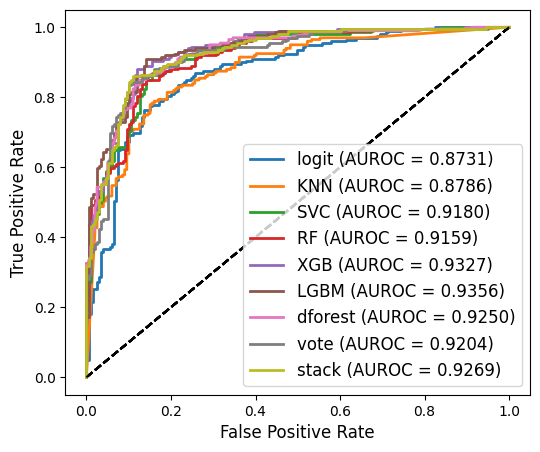

In [81]:
# Calculate ROC curves and AUC for each model
fpr, tpr, thresholds = roc_curve(y_test, y_thres_logit)
auroc = auc(fpr, tpr)

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_proba_knn)
auroc_knn = auc(fpr_knn, tpr_knn)

fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_thres_svc)
auroc_svc = auc(fpr_svc, tpr_svc)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
auroc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)
auroc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test, y_proba_lgbm)
auroc_lgbm = auc(fpr_lgbm, tpr_lgbm)

fpr_dforest, tpr_dforest, thresholds_dforest = roc_curve(y_test, y_proba_dforest)
auroc_dforest = auc(fpr_dforest, tpr_dforest)

fpr_vote, tpr_vote, thresholds_vote = roc_curve(y_test, y_proba_vote)
auroc_vote = auc(fpr_vote, tpr_vote)

fpr_stack, tpr_stack, thresholds_stack = roc_curve(y_test, y_proba_stack)
auroc_stack = auc(fpr_stack, tpr_stack)

# Define a function to plot the ROC curve
def plot_roc_curve(fpr, tpr, auroc, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=f'{label} (AUROC = {auroc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.grid(False)

# Plot all ROC curves
plt.figure(figsize=(6, 5))
plot_roc_curve(fpr, tpr, auroc, "logit")
plot_roc_curve(fpr_knn, tpr_knn, auroc_knn, "KNN")
plot_roc_curve(fpr_svc, tpr_svc, auroc_svc, "SVC")
plot_roc_curve(fpr_rf, tpr_rf, auroc_rf, "RF")
plot_roc_curve(fpr_xgb, tpr_xgb, auroc_xgb, "XGB")
plot_roc_curve(fpr_lgbm, tpr_lgbm, auroc_lgbm, "LGBM")
plot_roc_curve(fpr_dforest, tpr_dforest, auroc_dforest, "dforest")
plot_roc_curve(fpr_vote, tpr_vote, auroc_vote, "vote")
plot_roc_curve(fpr_stack, tpr_stack, auroc_stack, "stack")

plt.legend(loc="best", fontsize=12)
#plt.savefig('Eco_roc.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#**Evaluation**

In [82]:
# Print classification report for lgbm
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       199
           1       0.88      0.86      0.87       199

    accuracy                           0.87       398
   macro avg       0.87      0.87      0.87       398
weighted avg       0.87      0.87      0.87       398



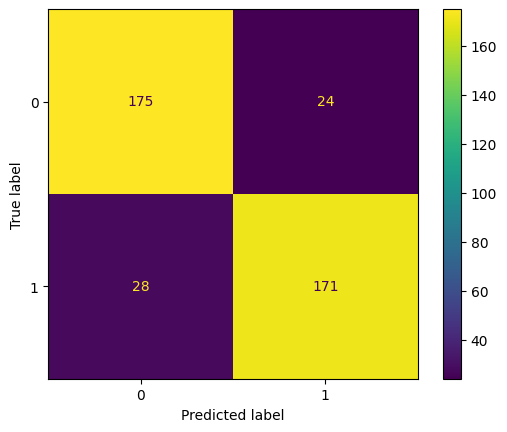

In [83]:
# Plot confusion matrix for lgbm model
cm = confusion_matrix(y_test, y_pred_lgbm, labels=lgbm_tuned.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lgbm_tuned.classes_)
disp.plot()

In [84]:
# Visualize observations that were incorrectly labeled
Flabel = pd.DataFrame(X_test[y_test != y_pred_lgbm])
Flabel

<IPython.core.display.Javascript object>

,Q,frac_CC,ECFP0,ECFP1,ECFP2,ECFP3,ECFP4,ECFP5,ECFP6,ECFP7,...,ECFP1014,ECFP1015,ECFP1016,ECFP1017,ECFP1018,ECFP1019,ECFP1020,ECFP1021,ECFP1022,ECFP1023
1985,0.021650,0.037006,-0.007307,0.002952,0.002498,0.000000,0.125568,0.064949,0.032475,0.000000,...,0.000000,0.064949,0.003247,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
504,0.000000,-0.042243,0.051457,0.076765,0.056836,0.000000,-0.031666,0.000000,0.052776,0.000000,...,0.000000,0.000000,0.063331,0.052776,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1069,0.000000,-0.002211,-0.030596,-0.023019,-0.025970,0.063301,0.056268,-0.021100,0.168804,0.000000,...,0.000000,0.063301,-0.025321,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
590,0.000000,0.013130,-0.045655,-0.034180,-0.024790,-0.026856,0.071616,0.080568,0.000000,0.000000,...,0.000000,0.080568,-0.032227,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1870,-0.012998,0.042605,-0.015598,-0.003545,-0.011999,0.000000,0.088390,0.077991,0.000000,0.000000,...,0.000000,0.097489,-0.003900,0.038995,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025,0.021318,-0.018761,-0.047966,-0.029070,-0.029517,-0.031977,0.051163,0.063954,0.000000,0.000000,...,0.000000,0.063954,-0.031977,0.000000,0.000000,0.063954,0.000000,0.000000,0.000000,0.000000
639,-0.055380,-0.001839,-0.012461,0.015104,0.000000,0.000000,-0.033228,-0.041535,0.000000,0.000000,...,0.000000,-0.041535,0.008307,0.083070,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
237,0.026763,-0.093834,0.008029,0.014598,0.037056,0.000000,-0.032115,-0.020072,0.000000,0.000000,...,0.000000,-0.020072,0.012043,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080288
1137,0.015376,0.000399,0.014415,0.014677,0.017742,0.000000,0.001538,0.000000,0.000000,0.000000,...,0.046129,-0.011532,0.016145,0.023064,0.000000,0.000000,0.000000,0.023064,0.046129,0.000000
2593,0.030023,0.009555,0.052915,0.065504,0.051963,0.067551,0.024018,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.054041,0.090068,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#**Feature importance**

In [85]:
# Find shap values
explainer = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(X_test)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


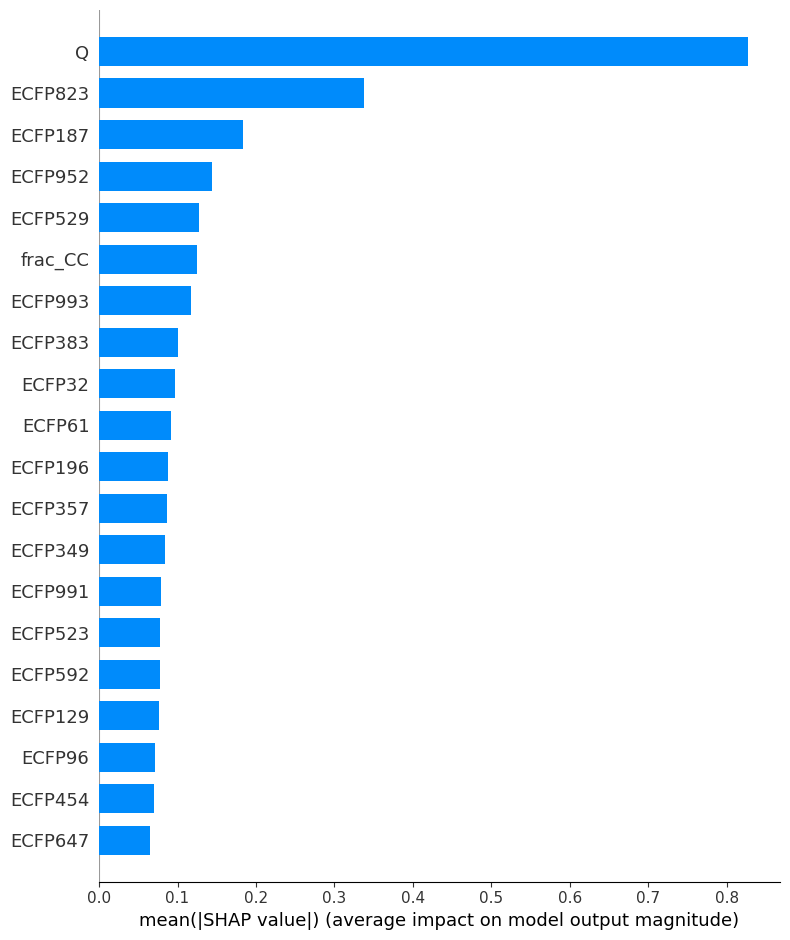

In [86]:
# Bar plot of shap values for class 1
shap.summary_plot(shap_values[1], X_test, plot_type='bar')

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


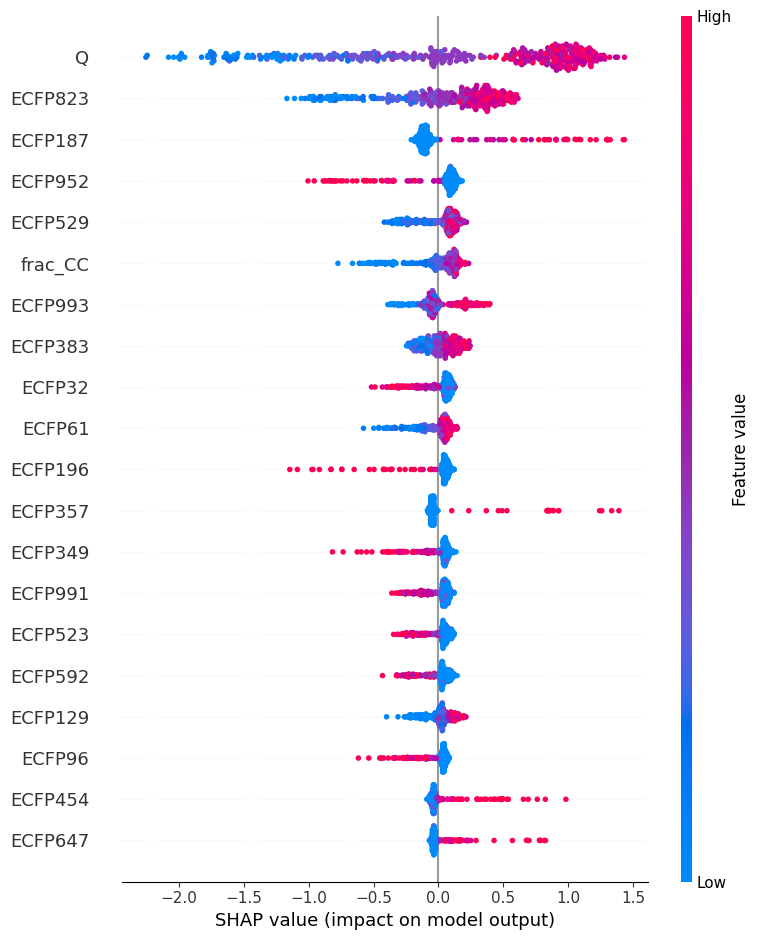

In [87]:
# Beeswarm plot of shap values
shap.summary_plot(shap_values[1], X_test)